## ОТЧЕТ ПО ЛАБОРАТОРНОЙ РАБОТЕ №1
### Тема: «Интерполяционный многочлен Ньютона»

**Вариант №9**

<b>Выполнил:</b><br>
Студент группы 4 КТС<br>
Минковский В. В.

In [1]:
# импорт библиотек
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# Целевые функуии
def target_function_1(x):
    """
    f1(x) = sin(x).
    """
    return np.sin(x)


def target_function_2(x):
    """
    f2(x) = sqrt(|x| + 4).
    """
    return np.sqrt(np.abs(x) + 4)

Здесь реализовано математическое ядро программы

### Выбор узлов интерполяции
Для построения интерполяционного многочлена степени $n$ требуется задать сетку из $n+1$ узлов на отрезке $[a, b]$. В работе рассматриваются два типа сеток:

1. **Равноотстоящие узлы (равномерная сетка):**
   Узлы располагаются на одинаковом расстоянии друг от друга $h = \frac{b-a}{n}$. Вычисляются по формуле:
   $$x_i = a + i\frac{b-a}{n}, \quad i = 0, ..., n$$
   *Проблема равномерной сетки:* для негладких функций использование таких узлов при больших $n$ приводит к расходимости интерполяционного процесса на краях отрезка.

2. **Оптимальные (чебышевские) узлы:**
   Для минимизации остатка интерполирования узлы выбираются как корни многочлена Чебышёва, спроецированные на заданный отрезок $[a, b]$. Узлы сгущаются к краям отрезка и вычисляются по формуле:
   $$x_i = \frac{a+b}{2} + \frac{b-a}{2} \cos\left(\frac{(2i+1)\pi}{2(n+1)}\right), \quad i = 0, ..., n$$
   Интерполяционный процесс по чебышевским узлам равномерно сходится для любой абсолютно непрерывной функции.

### Интерполяционный многочлен в форме Ньютона
Интерполяционный многочлен ищется в форме Ньютона, так как эта форма удобна для вычислений и позволяет легко добавлять новые узлы:
$$P_n(x) = \alpha_0 + \alpha_1(x - x_0) + \alpha_2(x - x_0)(x - x_1) + \dots + \alpha_n(x - x_0)\dots(x - x_{n-1})$$

Коэффициентами $\alpha_i$ данного многочлена являются **разделённые разности** порядка $i$:
$$\alpha_i = f[x_0, \dots, x_i]$$
Они вычисляются по рекуррентному соотношению:
$$f[x_0, \dots, x_k] = \frac{f[x_1, \dots, x_k] - f[x_0, \dots, x_{k-1}]}{x_k - x_0}$$
*Программная реализация:* Для экономии оперативной памяти матрица разделённых разностей не строится целиком. Вычисления производятся на месте в одномерном массиве путём его обхода с конца в начало.

### Схема Горнера
Для вычисления значения построенного многочлена $P_n(x)$ в произвольной точке используется схема Горнера. Она заключается в последовательном вынесении за скобки общих множителей $(x - x_i)$:
$$P_n(x) = \alpha_0 + (x - x_0) \Big(\alpha_1 + (x - x_1) \big(\alpha_2 + \dots \big)\Big)$$
Этот алгоритм является вычислительно устойчивым и минимизирует количество арифметических операций умножения.


*Ниже представлена программная реализация описанных математических методов:*

In [3]:
def get_uniform_nodes(a, b, n):
    """
    Генерация равномерной сетки узлов.
    """
    return np.linspace(a, b, n + 1)


def get_chebyshev_nodes(a, b, n):
    """
    Генерация оптимальных (чебышевских) узлов интерполяции.
    """
    indices = np.arange(n + 1)
    return (a + b) / 2 + (b - a) / 2 * np.cos((2 * indices + 1) * np.pi / (2 * (n + 1)))


def calculate_divided_differences(x_nodes, y_nodes):
    """
    Вычисление разделенных разностей (коэффициентов полинома Ньютона).
    """
    n = len(x_nodes)
    coefficients = np.copy(y_nodes).astype(float)
    
    for step in range(1, n):
        for index in range(n - 1, step - 1, -1):
            numerator = coefficients[index] - coefficients[index - 1]
            denominator = x_nodes[index] - x_nodes[index - step]
            coefficients[index] = numerator / denominator
            
    return coefficients


def evaluate_newton_polynomial(x_eval, x_nodes, coefficients):
    """
    Вычисление значения многочлена Ньютона в точке (или массиве точек)
    с использованием вычислительно эффективной схемы Горнера.
    """
    degree = len(coefficients) - 1
    result = coefficients[degree]
    
    for index in range(degree - 1, -1, -1):
        result = coefficients[index] + (x_eval - x_nodes[index]) * result
        
    return result

## Вычислительный эксперимент и визуализация результатов

Здесь реализован инструментарий для проведения вычислительного эксперимента, оценки точности построенных многочленов и визуализации полученных данных. 

В соответствии с заданием, процесс разбит на три составляющие:

###  1. Экспорт данных
Функция `save_data_to_file` отвечает за сохранение сгенерированных точек интерполяционного многочлена $(x_i, P_n(x_i))$ в текстовые файлы. Сохранение производится для плотной сетки (501 точка), что позволяет в дальнейшем использовать эти данные во внешних программах.

###  2. Визуализация интерполяционных многочленов
Функция `plot_interpolation_graphs` строит совмещенные графики исходной функции $f(x)$ и построенных многочленов Ньютона $P_n(x)$ для заданных степеней $n \in \{2, 10, 20\}$. 
* Графики позволяют визуально оценить поведение многочлена между узлами интерполяции. 
* Сравнение верхнего ряда графиков (равномерная сетка) и нижнего (чебышевские узлы) наглядно демонстрирует разницу в поведении полиномов на краях отрезка при увеличении $n$.

###  3. Анализ сходимости интерполяционного процесса
Функция `plot_convergence` позволяет эмпирически исследовать сходимость интерполяционного процесса при $n \to \infty$ (в нашем случае $n$ варьируется от 1 до 61). 

Для оценки качества приближения используется **равномерная норма остатка интерполирования** (пространство $C[a,b]$):
$$ \varepsilon_n = \| r_n \|_{C[a,b]} = \max_{x \in [a,b]} | P_n(x) - f(x) | $$

**Теоретическое обоснование эксперимента:**
1. Построение графика в логарифмическом масштабе по оси $Oy$ необходимо, так как погрешность может изменяться на много порядков.
2. Для недостаточно гладких функций ожидается проявление **феномена Рунге** на равномерной сетке: норма погрешности $\varepsilon_n$ начнет экспоненциально возрастать при увеличении $n$.
3. Использование **чебышевских узлов** должно гарантировать убывание нормы погрешности (сходимость $\|P_n - f\| \to 0$) для любой абсолютно непрерывной функции.

---
*Ниже представлены функции для сохранения данных и генерации графиков эксперимента:*

In [ ]:
def save_data_to_file(filename, x_data, y_data):
    """
    Сохранение набора точек в файл СТРОГО по заданию.
    Формат: два столбца чисел (x и P_n(x)), разделенных табуляцией.
    """
    # Объединяем x и y в два столбца
    data = np.column_stack((x_data, y_data))
    
    # Сохраняем данные
    np.savetxt(filename, data, fmt='%.6f', delimiter='\t')
    print(f"Файл сохранен: {filename}")


def plot_interpolation_graphs(func, a, b, func_name):
    """
    Построение графиков и сохранение данных.
    """
    degrees = [2, 10, 20]

    dense_x = get_uniform_nodes(a, b, 500)

    exact_y = func(dense_x)

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f'Интерполяция функции {func_name}', fontsize=16)

    for col_index, n in enumerate(degrees):
        f_name = func.__name__ 

        # Равномерные узлы
        nodes_u = get_uniform_nodes(a, b, n)
        coefs_u = calculate_divided_differences(nodes_u, func(nodes_u))
        poly_u = evaluate_newton_polynomial(dense_x, nodes_u, coefs_u)

        # Сохраняем данные (x, Pn(x)) для равномерных узлов
        save_data_to_file(f'Pn_uniform_{f_name}_n{n}.txt', dense_x, poly_u)

        # Рисуем график
        ax_uni = axes[0, col_index]
        ax_uni.plot(dense_x, exact_y, 'b-', label='f(x)')
        ax_uni.plot(dense_x, poly_u, 'r--', label=f'P_{n}(x)')
        ax_uni.scatter(nodes_u, func(nodes_u), color='black', zorder=5)
        ax_uni.set_title(f'Равномерные узлы (n={n})')
        ax_uni.grid(True)
        ax_uni.legend()

        # Чебышевские узлы
        nodes_c = get_chebyshev_nodes(a, b, n)
        coefs_c = calculate_divided_differences(nodes_c, func(nodes_c))
        poly_c = evaluate_newton_polynomial(dense_x, nodes_c, coefs_c)

        # Сохраняем данные (x, Pn(x)) для чебышевских узлов
        save_data_to_file(f'Pn_chebyshev_{f_name}_n{n}.txt', dense_x, poly_c)

        # Рисуем график
        ax_cheb = axes[1, col_index]
        ax_cheb.plot(dense_x, exact_y, 'b-', label='f(x)')
        ax_cheb.plot(dense_x, poly_c, 'g--', label=f'P_{n}(x)')
        ax_cheb.scatter(nodes_c, func(nodes_c), color='black', zorder=5)
        ax_cheb.set_title(f'Чебышевские узлы (n={n})')
        ax_cheb.grid(True)
        ax_cheb.legend()

    plt.tight_layout()
    plt.show()


def plot_convergence(func, a, b, func_name):
    """
    Построение графика сходимости (логарифмическая шкала).
    """
    degrees = range(1, 62, 5)
    
    dense_x = get_uniform_nodes(a, b, 500)
    exact_y = func(dense_x)
    
    errors_u = []
    errors_c = []

    for n in degrees:
        # Равномерные
        nodes_u = get_uniform_nodes(a, b, n)
        coefs_u = calculate_divided_differences(nodes_u, func(nodes_u))
        poly_u = evaluate_newton_polynomial(dense_x, nodes_u, coefs_u)
        errors_u.append(np.max(np.abs(poly_u - exact_y)))

        # Чебышевские
        nodes_c = get_chebyshev_nodes(a, b, n)
        coefs_c = calculate_divided_differences(nodes_c, func(nodes_c))
        poly_c = evaluate_newton_polynomial(dense_x, nodes_c, coefs_c)
        errors_c.append(np.max(np.abs(poly_c - exact_y)))

    plt.figure(figsize=(12, 6))
    plt.semilogy(degrees, errors_u, 'ro-', label='Равномерные узлы')
    plt.semilogy(degrees, errors_c, 'gs-', label='Чебышевские узлы')
    
    plt.title(f'Сходимость интерполяционного процесса для {func_name}')
    plt.xlabel('Степень многочлена (n)')
    plt.ylabel('Макс. погрешность ||r_n|| (log)')
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()

## Теперь проводим эксперименты


Запуск вычислений для отрезка [-3, 3]...

--- Эксперимент для f1(x) = sin(x) ---
Файл сохранен: Pn_uniform_target_function_1_n2.txt
Файл сохранен: Pn_chebyshev_target_function_1_n2.txt
Файл сохранен: Pn_uniform_target_function_1_n10.txt
Файл сохранен: Pn_chebyshev_target_function_1_n10.txt
Файл сохранен: Pn_uniform_target_function_1_n20.txt
Файл сохранен: Pn_chebyshev_target_function_1_n20.txt


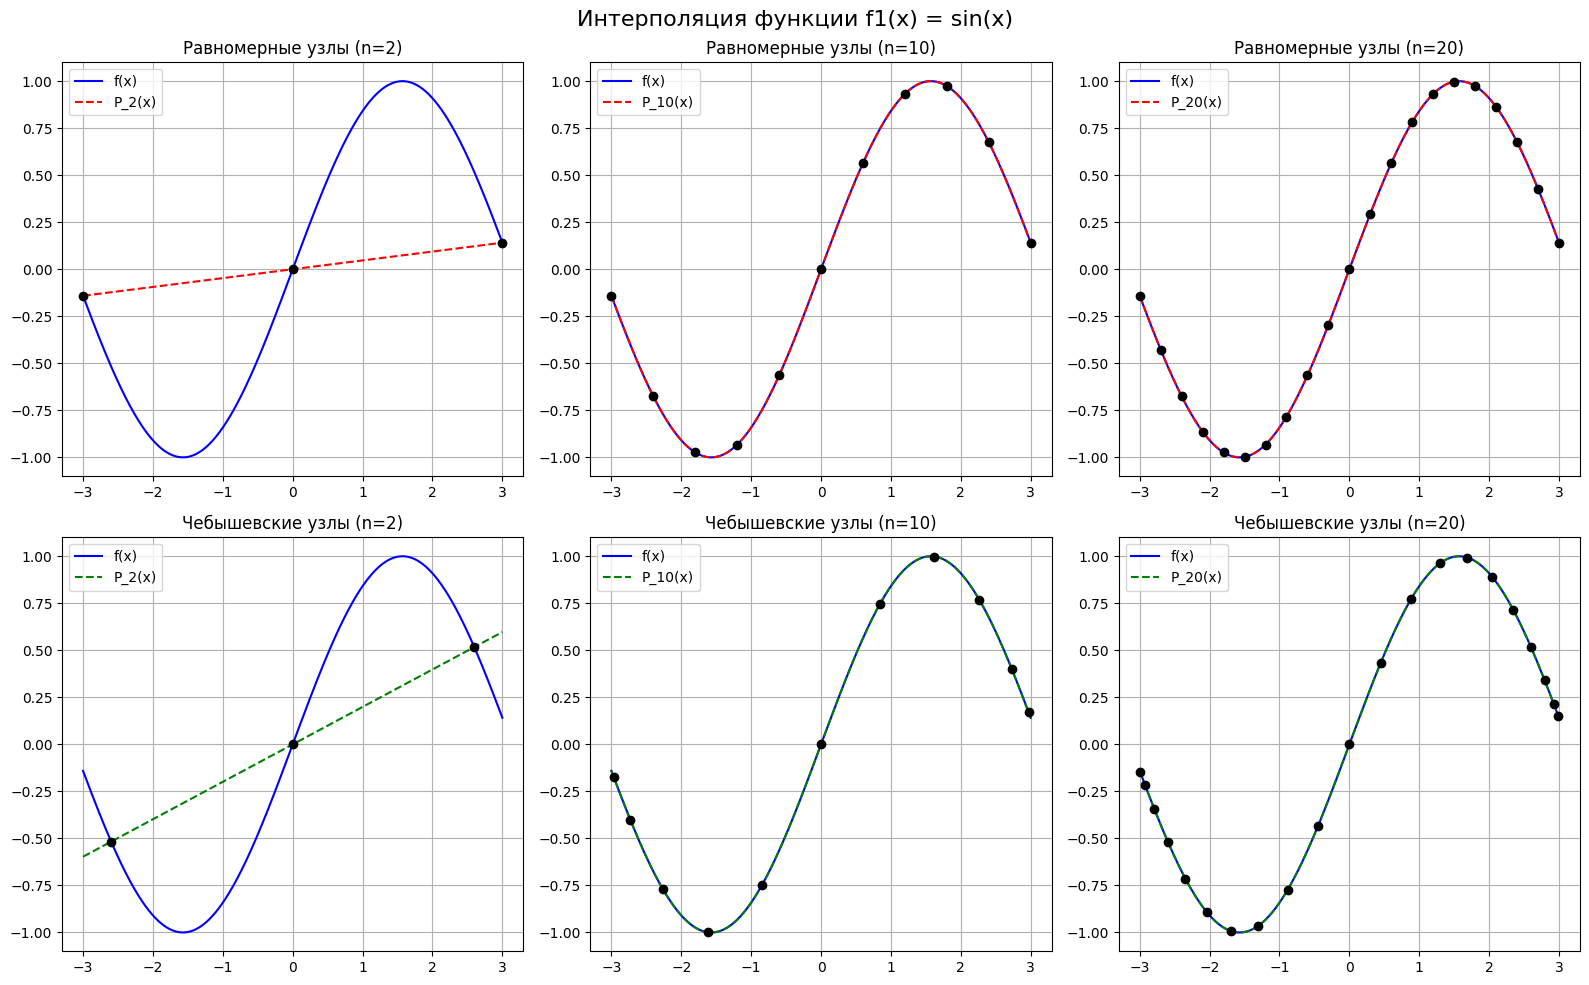

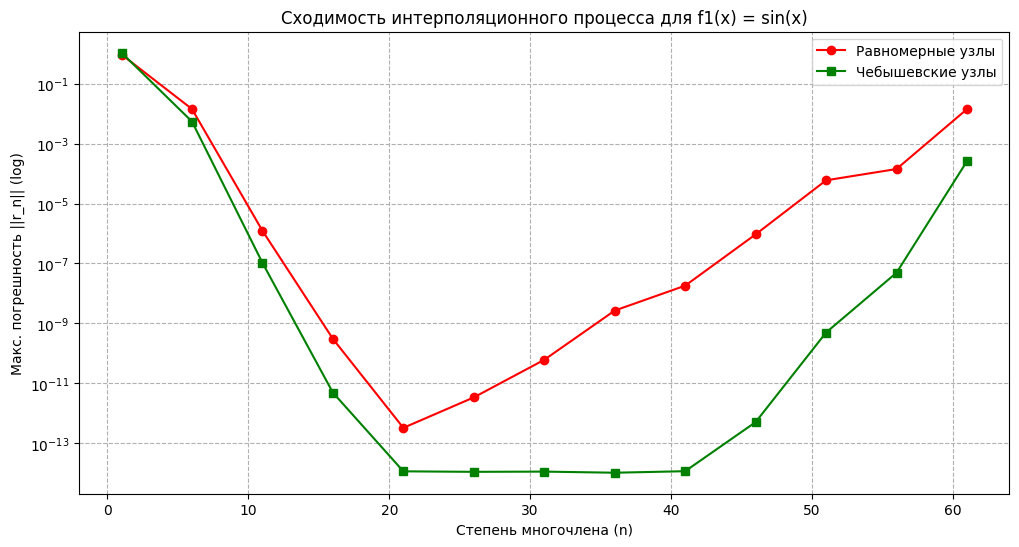


--- Эксперимент для f2(x) = sqrt(|x| + 4) ---
Файл сохранен: Pn_uniform_target_function_2_n2.txt
Файл сохранен: Pn_chebyshev_target_function_2_n2.txt
Файл сохранен: Pn_uniform_target_function_2_n10.txt
Файл сохранен: Pn_chebyshev_target_function_2_n10.txt
Файл сохранен: Pn_uniform_target_function_2_n20.txt
Файл сохранен: Pn_chebyshev_target_function_2_n20.txt


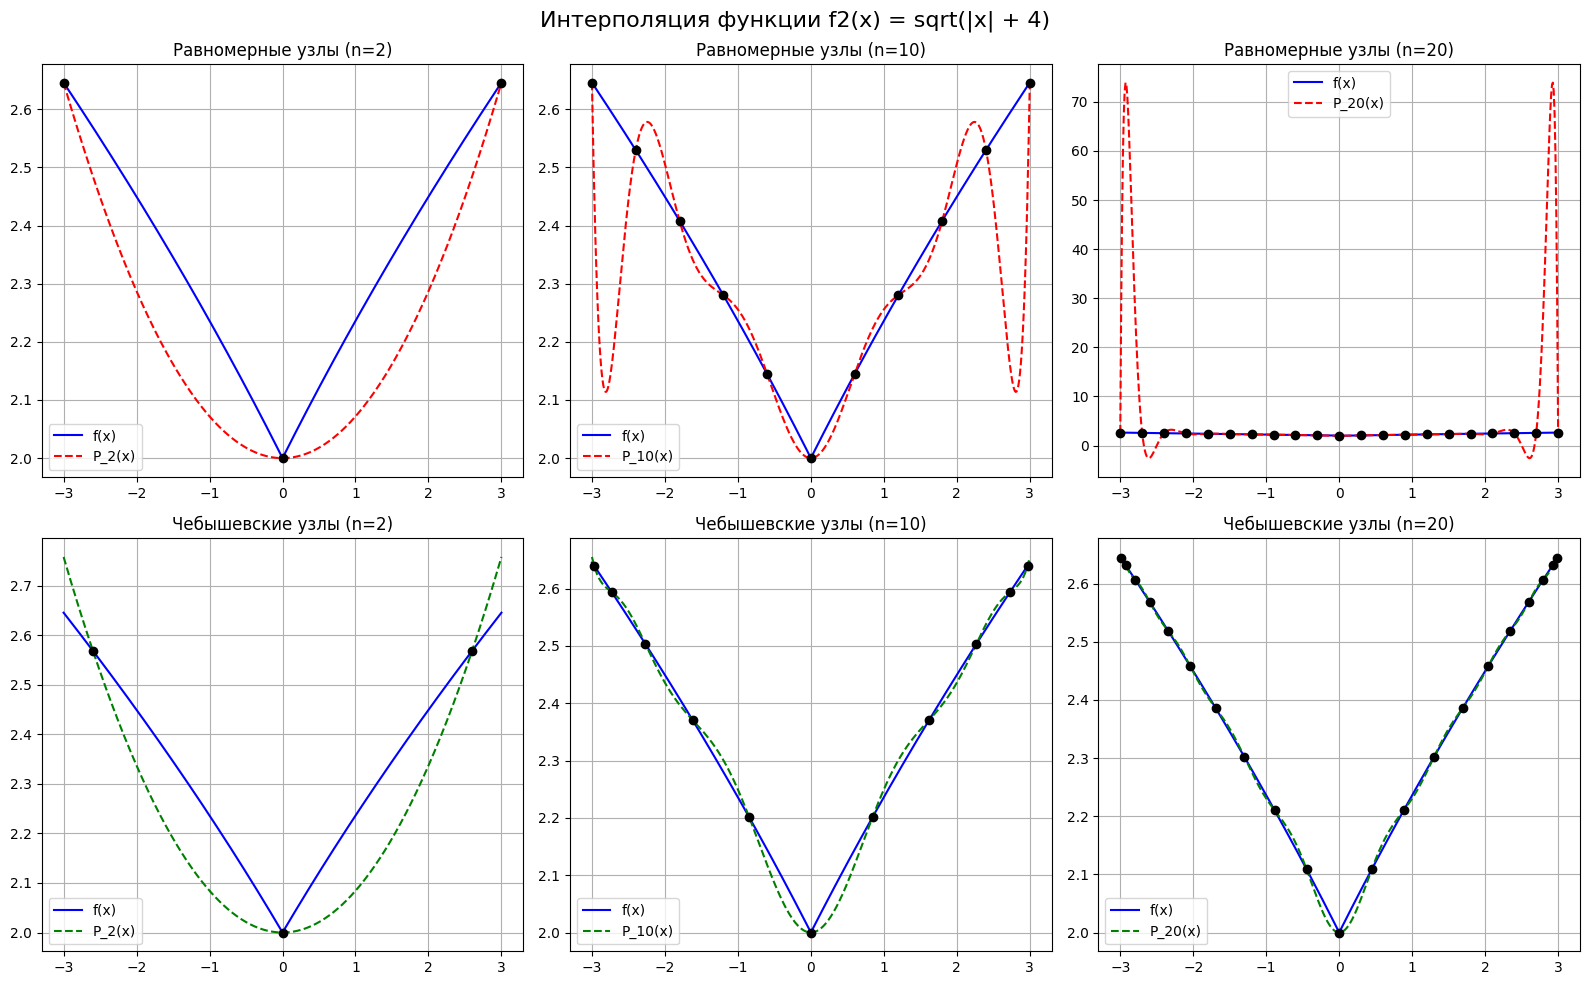

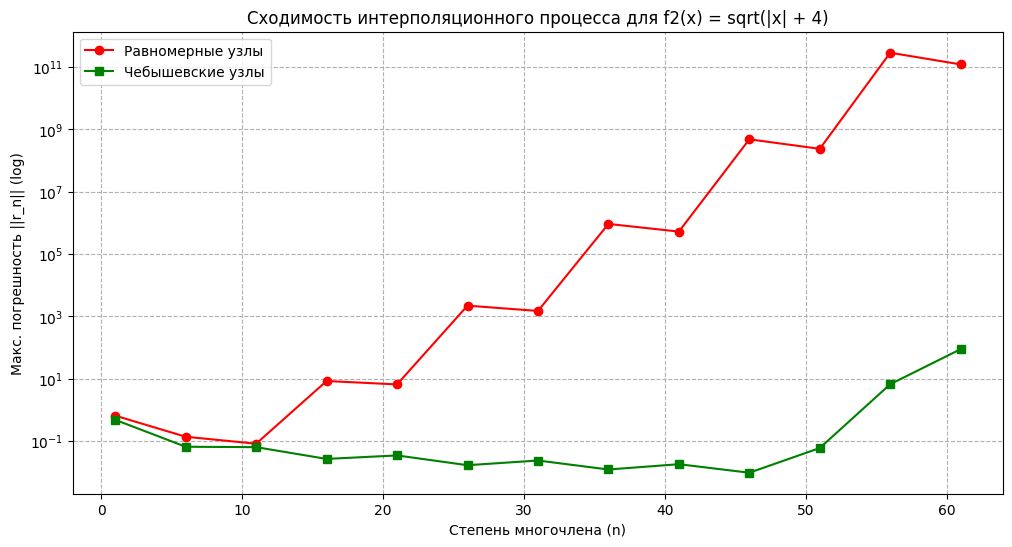


Эксперимент успешно завершен. Все точки сохранены в .txt файлы в текущей директории.


In [5]:
def main():
    

    segment_a=-3
    segment_b = 3

    print(f"\nЗапуск вычислений для отрезка [{segment_a}, {segment_b}]...")

    print("\n--- Эксперимент для f1(x) = sin(x) ---")
    plot_interpolation_graphs(target_function_1, segment_a, segment_b, "f1(x) = sin(x)")
    plot_convergence(target_function_1, segment_a, segment_b, "f1(x) = sin(x)")

    print("\n--- Эксперимент для f2(x) = sqrt(|x| + 4) ---")
    plot_interpolation_graphs(target_function_2, segment_a, segment_b, "f2(x) = sqrt(|x| + 4)")
    plot_convergence(target_function_2, segment_a, segment_b, "f2(x) = sqrt(|x| + 4)")

    print("\nЭксперимент успешно завершен. Все точки сохранены в .txt файлы в текущей директории.")


# Запуск программы
main()

## Выводы по результатам вычислительного эксперимента

На основании проведенного вычислительного эксперимента и визуального анализа полученных графиков можно сделать следующие выводы о свойствах полиномиальной интерполяции.

### Интерполяция аналитически гладкой функции $f_1(x) = \sin(x)$
1. **Качество приближения:** Функция $\sin(x)$ является бесконечно дифференцируемой (целой). Как видно из графиков интерполяции, для таких функций процесс сходится очень быстро. Уже при $n=10$ и $n=20$ многочлен визуально полностью совпадает с исходной функцией как на равномерной, так и на чебышевской сетке.
2. **Анализ сходимости:** График максимальной погрешности в логарифмическом масштабе показывает стремительное экспоненциальное убывание ошибки до уровня машинной точности ($10^{-13} \dots 10^{-14}$) при $n \approx 20$.
3. **Вычислительная устойчивость:** На графике сходимости для равномерной сетки (красная линия) видно, что при $n > 20$ ошибка начинает расти. Это связано не с математической расходимостью метода, а с накоплением ошибок машинного округления при решении систем высокой размерности. Чебышевская сетка (зеленая линия) сохраняет вычислительную стабильность значительно дольше.

### Интерполяция функции с изломом $f_2(x) = \sqrt{|x| + 4}$
1. **Проявление феномена Рунге:** Данная функция содержит модуль, из-за чего её первая производная в точке $x=0$ терпит разрыв (функция недостаточно гладкая). Графики интерполяции для равномерных узлов наглядно демонстрируют **феномен Рунге**: при увеличении степени многочлена (особенно при $n=20$) на концах отрезка возникают сильные осцилляции (раскачивания) с огромной амплитудой.
2. **Расходимость процесса:** График сходимости для равномерной сетки неопровержимо доказывает расходимость: норма погрешности $\|r_n\|$ катастрофически растет при увеличении $n$, достигая значений порядка $10^{11}$. 
3. **Эффективность чебышевских узлов:** Использование корней многочлена Чебышёва полностью решает проблему краевых осцилляций. На графиках интерполяции при $n=20$ полином идет строго по функции, а график погрешности показывает, что ошибка подавляется и остается в разумных пределах, предотвращая глобальную расходимость.

### Итоговый вывод
Эксперимент полностью подтверждает теоретические положения вычислительной математики:
* Использование **равномерной сетки** узлов для построения интерполяционных многочленов высоких степеней недопустимо для недостаточно гладких функций, так как неизбежно приводит к возникновению феномена Рунге и расходимости процесса.
* Использование **чебышевских узлов** является оптимальной стратегией. Этот подход подавляет краевые осцилляции и гарантирует сходимость (или стабильное поведение) интерполяционного процесса даже для функций, имеющих особенности в производных.